# 03 - Model Experiments

## Objective
This notebook trains and compares baseline machine learning models for the fee defaulter prediction task.

Two feature set will be evaluated:
- **Full dataset**: includes all engineered predictors
- **Strict dataset**: excludes variables directly used in target construction

The goal is to compare predictive performance while being mindful of potential leakage effects.

In [43]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay)

import joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
project_root = Path("/content/drive/MyDrive/fee-defaulter-prediction")

full_path = project_root / "data" / "processed" / "02_features_full.csv"
strict_path = project_root / "data" / "processed" / "02_features_strict.csv"

(project_root / "models").mkdir(parents=True, exist_ok=True)
(project_root / "reports").mkdir(parents=True, exist_ok=True)
(project_root / "reports" / "figures").mkdir(parents=True, exist_ok=True)

In [45]:
df_full = pd.read_csv(full_path)
df_strict = pd.read_csv(strict_path)

print("Full:", df_full.shape)
print("strict:", df_strict.shape)

Full: (395, 37)
strict: (395, 34)


In [46]:
from re import X
target_col = "default"

X_full = df_full.drop(columns=[target_col])
y_full = df_full[target_col]

X_strict = df_strict.drop(columns=[target_col])
y_strict = df_strict[target_col]

print("X_full:", X_full.shape, "y_full:", y_full.shape)
print("x_strict:", X_strict.shape, "y_strict:", y_strict.shape)

X_full: (395, 36) y_full: (395,)
x_strict: (395, 33) y_strict: (395,)


## Train-Test Split Strategy

Since this dataset does not include a true chronological timestamp for payment behaviour, a temporal split is not directly available.

Instead, a **stratified train-test split** is used to preserve the class balance of the engineered target in both training and testing sets.

In [47]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_strict, y_strict, test_size=0.2, random_state=42, stratify=y_strict
)

print("Full train/test:", Xf_train.shape, Xf_test.shape)
print("Strict train/test:", Xs_train.shape, Xs_test.shape)

Full train/test: (316, 36) (79, 36)
Strict train/test: (316, 33) (79, 33)


In [48]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
}


In [49]:
def evaluate_model(model, X_train, X_test, y_train, y_test, dataset_name, model_name):
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]

  results = {
      "dataset": dataset_name,
      "model": model_name,
      "accuracy": accuracy_score(y_test, y_pred),
      "precision": precision_score(y_test, y_pred),
      "recall": recall_score(y_test, y_pred),
      "f1": f1_score(y_test, y_pred),
      "roc_auc": roc_auc_score(y_test, y_prob)
  }
  return results, y_pred, y_prob, model

In [50]:
results = []
trained_models = {}

# Full dataset experiments
for model_name, model in models.items():
  res, y_pred, y_prob, fitted_model = evaluate_model(model, Xf_train, Xf_test, yf_train, yf_test, "full", model_name)
  results.append(res)
  trained_models[f"full_{model_name}"] = fitted_model

# Strict dataset experiments
for model_name, model in models.items():
  res, y_pred, y_prob, fitted_model = evaluate_model(model, Xs_train, Xs_test, ys_train, ys_test, "strict", model_name)
  results.append(res)
  trained_models[f"strict_{model_name}"] = fitted_model


In [51]:
results_df = pd.DataFrame(results).sort_values(by=["roc_auc", "f1"], ascending=False)
results_df

,dataset,model,accuracy,precision,recall,f1,roc_auc
1,full,Random Forest,0.949367,0.965517,0.903226,0.933333,0.995968
0,full,Logistic Regression,0.911392,1.000000,0.774194,0.872727,0.959677
3,strict,Random Forest,0.835443,0.875000,0.677419,0.763636,0.906586
2,strict,Logistic Regression,0.848101,0.880000,0.709677,0.785714,0.889113


## Metric Interpretation

The following metrics are used:

- **Accuracy**: overall correctness
- **Precision**: among predicted defaulters, how many were truly high-risk
- **Recall**: among true high-risk students, how many the model successfully identified
- **F1-Score**: balance between precision and recall
- **ROC-AUC**: ability to rank higher-risk students above lower_risk students

For this project, **recall** is especially important beacuse missing a genuinely high-risk student may be more costly than flagging an extra low_risk student.

In [52]:
best_row = results_df.iloc[0]
best_row

,1
dataset,full
model,Random Forest
accuracy,0.949367
precision,0.965517
recall,0.903226
f1,0.933333
roc_auc,0.995968


In [53]:
print("Best dataset:", best_row['dataset'])
print("Best model:",  best_row["model"])
print("ROC-AUC:", round(best_row["roc_auc"], 4))
print("F1:", round(best_row["f1"], 4))
print("Recall:", round(best_row["recall"], 4))
print("Precision:", round(best_row["precision"], 4))

Best dataset: full
Best model: Random Forest
ROC-AUC: 0.996
F1: 0.9333
Recall: 0.9032
Precision: 0.9655


Best dataset: full
Best model: Random Forest
Model key: full_Random Forest
Number of model features: 33
Number of test features: 36
Missing in test: set()
Extra in test: {'G3', 'absences', 'failures'}


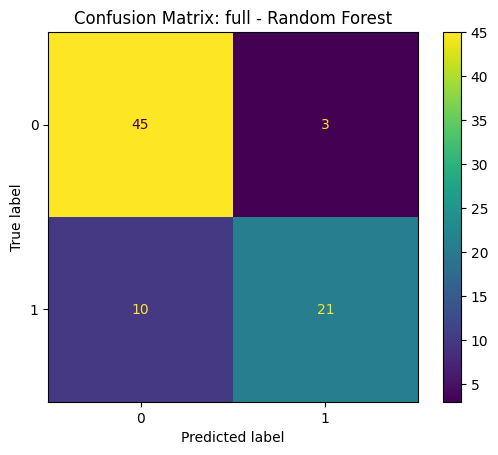

In [57]:
best_row = results_df.iloc[0]

best_dataset = best_row["dataset"]
best_model_name = best_row["model"]

print("Best dataset:", best_dataset)
print("Best model:", best_model_name)

# pick the correct split based on the winning dataset
if best_dataset == "full":
    X_train_best = Xf_train.copy()
    X_test_best = Xf_test.copy()
    y_train_best = yf_train.copy()
    y_test_best = yf_test.copy()
elif best_dataset == "strict":
    X_train_best = Xs_train.copy()
    X_test_best = Xs_test.copy()
    y_train_best = ys_train.copy()
    y_test_best = ys_test.copy()
else:
    raise ValueError(f"Unexpected dataset value: {best_dataset}")

# load the matching trained model
model_key = f"{best_dataset}_{best_model_name}"
print("Model key:", model_key)

best_model = trained_models[model_key]

# sanity check: compare model feature names to test-set columns
print("Number of model features:", len(best_model.feature_names_in_))
print("Number of test features:", len(X_test_best.columns))

missing_in_test = set(best_model.feature_names_in_) - set(X_test_best.columns)
extra_in_test = set(X_test_best.columns) - set(best_model.feature_names_in_)

print("Missing in test:", missing_in_test)
print("Extra in test:", extra_in_test)

# force exact feature order match
X_test_best = X_test_best[best_model.feature_names_in_]

# predict
y_best_pred = best_model.predict(X_test_best)

cm = confusion_matrix(y_test_best, y_best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix: {best_dataset} - {best_model_name}")
plt.show()

In [58]:
for key, model in trained_models.items():
    if hasattr(model, "feature_names_in_"):
        print(key, len(model.feature_names_in_))

full_Logistic Regression 33
full_Random Forest 33
strict_Logistic Regression 33
strict_Random Forest 33


In [59]:
results_path = project_root / "reports" / "model_results.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")

Saved results to: /content/drive/MyDrive/fee-defaulter-prediction/reports/model_results.csv


In [60]:
best_model_path = project_root / "models" / "best_model.pkl"
joblib.dump(best_model, best_model_path)

print(f"Saved best model to: {best_model_path}")

Saved best model to: /content/drive/MyDrive/fee-defaulter-prediction/models/best_model.pkl


In [61]:
if best_dataset == "full":
    X_train_best.to_csv(project_root / "data" / "processed" / "03_best_X_train.csv", index=False)
    X_test_best.to_csv(project_root / "data" / "processed" / "03_best_X_test.csv", index=False)
    y_train_best.to_csv(project_root / "data" / "processed" / "03_best_y_train.csv", index=False)
    y_test_best.to_csv(project_root / "data" / "processed" / "03_best_y_test.csv", index=False)
else:
    X_train_best.to_csv(project_root / "data" / "processed" / "03_best_X_train.csv", index=False)
    X_test_best.to_csv(project_root / "data" / "processed" / "03_best_X_test.csv", index=False)
    y_train_best.to_csv(project_root / "data" / "processed" / "03_best_y_train.csv", index=False)
    y_test_best.to_csv(project_root / "data" / "processed" / "03_best_y_test.csv", index=False)

print("Saved best train/test split for Notebook 04.")

Saved best train/test split for Notebook 04.


## Notebook 03 Summary

This notebook trained two baseline models on both the full and strict feature sets:

- Logistic Regression
- Random Forest

The experiments compared performance across accuracy, precision, recall, F1-score, and ROC-AUC.

The best-performing model was saved for later explainability analysis in Notebook 04.